In [1]:
# import pandas as pd
# import warnings
# warnings.filterwarnings("ignore") # Clean up output for presentation

# # Visualization tools
# import pyLDAvis.lda_model

# # Neural Tools
# from bertopic import BERTopic
# from transformers import AutoModel, AutoTokenizer

# # LDA Tools (ArtificiAI)
# try:
#     from artifici_lda.lda_service import train_lda_pipeline_default
# except ImportError:
#     print("Error: artifici_lda not found. Please install via: pip install git+https://github.com/ArtificiAI/Multilingual-Latent-Dirichlet-Allocation-LDA.git")

## Data Exploration

### Dataset

In [ ]:
from nlp_topic_modeling.data.loaders import load_MOROCO

df, columns = load_MOROCO()
print(f"\nDataset shape and columns:")
print(f"\tShape: {df.shape}")
print(f"\tColumns: {columns}")

/home/astanea/git-repos/adrianstanea/NLP-Topic-Modeling/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- Loading MOROCO from Hugging Face ---
	Loaded 21719 documents.

Dataset shape and columns:
	Shape: (21719, 2)
	Columns: ['category', 'sample']



Class distribution:
  2: 5910 documents
  1: 5522 documents
  4: 3899 documents
  5: 3014 documents
  3: 1890 documents
  0: 1484 documents


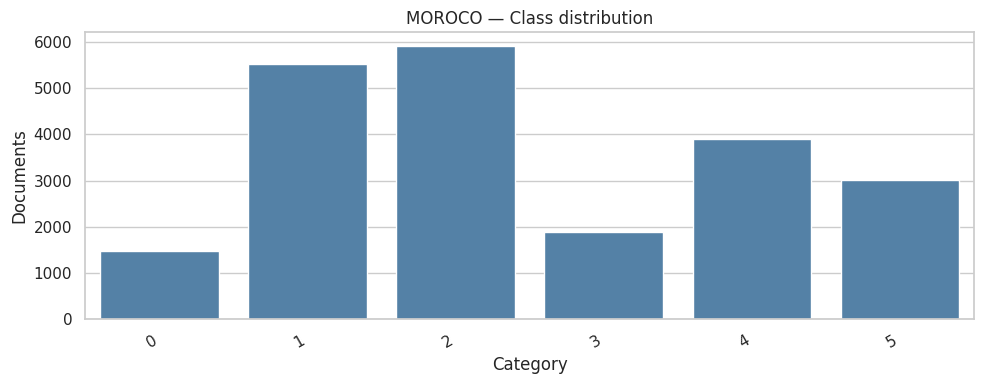

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

class_counts = (
    df["category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="count")
)

print("\nClass distribution:")
for _, row in class_counts.iterrows():
    print(f"  {row['category']}: {row['count']} documents")

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 4))
ax = sns.barplot(data=class_counts, x="category", y="count", color="steelblue")
ax.set_title("MOROCO — Class distribution")
ax.set_xlabel("Category")
ax.set_ylabel("Documents")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [4]:
# Visualize how the first N documents look like
N = 5
print(f"\nFirst {N} documents in the dataset:")
for i in range(N):
    print(f"\nDocument {i+1}:")
    print(f"Category: {df.loc[i, 'category']}")
    print(f"Text: {df.loc[i, 'sample'][:500]}...")  # Print first 500 characters


First 5 documents in the dataset:

Document 1:
Category: 2
Text: “$NE$ cum am spus, nu este un sfârşit de drum . Vom continua lupta cu toate instrumentele şi cu toate mijloacele legale, parlamentare şi civice pe care le avem la dispoziţie . Evident că vom contesta la $NE$ această lege, au anunţat şi colegii de la $NE$ o astfel de contestaţie . Practic trebuie utilizat orice instrument pe care îl identificăm pentru a bloca intrarea în vigoare a acestei legi . Bineînţeles, şi preşedintele are punctul său de vedere . ( . . . ) $NE$ legi sunt împănate de motive d...

Document 2:
Category: 2
Text: Liberal - democratul $NE$ $NE$ renunţă la mandatul de deputat şi anunţă că revine în funcţia de preşedinte al raionului $NE$ $NE$ . „$NE$ decizia şi solicitarea echipei din $NE$ $NE$ cu care am muncit nouă ani”, a declarat $NE$ pentru $NE$ . Cererea de renunţare la mandatul de deputat a fost trimisă preşedintelui $NE$ $NE$ $NE$ . $NE$ a participat la o singură şedinţă a $NE$ mandatul de deputat f

## Method 1: LDA

In [8]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

RO_STOPWORDS = stopwords.words('romanian')
print(RO_STOPWORDS)

['a', 'abia', 'acea', 'aceasta', 'această', 'aceea', 'aceeasi', 'acei', 'aceia', 'acel', 'acela', 'acelasi', 'acele', 'acelea', 'acest', 'acesta', 'aceste', 'acestea', 'acestei', 'acestia', 'acestui', 'aceşti', 'aceştia', 'adica', 'ai', 'aia', 'aibă', 'aici', 'al', 'ala', 'ale', 'alea', 'alt', 'alta', 'altceva', 'altcineva', 'alte', 'altfel', 'alti', 'altii', 'altul', 'am', 'anume', 'apoi', 'ar', 'are', 'as', 'asa', 'asta', 'astea', 'astfel', 'asupra', 'atare', 'atat', 'atata', 'atatea', 'atatia', 'ati', 'atit', 'atita', 'atitea', 'atitia', 'atunci', 'au', 'avea', 'avem', 'aveţi', 'avut', 'aş', 'aţi', 'ba', 'ca', 'cam', 'cand', 'care', 'careia', 'carora', 'caruia', 'cat', 'catre', 'ce', 'cea', 'ceea', 'cei', 'ceilalti', 'cel', 'cele', 'celor', 'ceva', 'chiar', 'ci', 'cind', 'cine', 'cineva', 'cit', 'cita', 'cite', 'citeva', 'citi', 'citiva', 'cu', 'cui', 'cum', 'cumva', 'cât', 'câte', 'câtva', 'câţi', 'cînd', 'cît', 'cîte', 'cîtva', 'cîţi', 'că', 'căci', 'cărei', 'căror', 'cărui', 'căt

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/astanea/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
print("\n--- Method 1: Training LDA Model (Statistical) ---")

docs_list = df['sample'].tolist()
n_topics = df['category'].nunique()


--- Method 1: Training LDA Model (Statistical) ---


In [ ]:
from nlp_topic_modeling.lda import lda_pipeline
from nlp_topic_modeling.lda.config import ROMANIAN

transformed_docs, top_docs, unigrams, bigrams = lda_pipeline(
    docs_list=docs_list,
    n_topics=n_topics,
    language=ROMANIAN,
    stopwords=RO_STOPWORDS
)

In [ ]:


# Train the pipeline
transformed_docs, top_docs, unigrams, bigrams = train_lda_pipeline_default(
    docs_list,
    n_topics=6,
    stopwords=RO_STOPWORDS,
    language='romanian'
)

# Display results
print("\n[LDA] Top Topic Keywords (Bigrams):")
for i, topic in enumerate(bigrams):
    # Print top 5 bigrams for the topic
    clean_grams = [t[0] for t in topic[:5]]
    print(f"Topic {i}: {clean_grams}")


--- Method 1: Training LDA Model (Statistical) ---


114.29s - Error patching args (debugger not attached to subprocess).
Traceback (most recent call last):
  File "/home/astanea/git-repos/adrianstanea/NLP-Topic-Modeling/.venv/lib/python3.12/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py", line 541, in patch_args
    new_args.append(_get_python_c_args(host, port, code, unquoted_args, SetupHolder.setup))
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/astanea/git-repos/adrianstanea/NLP-Topic-Modeling/.venv/lib/python3.12/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py", line 193, in _get_python_c_args
    if "__future__" in code:
       ^^^^^^^^^^^^^^^^^^^^
TypeError: a bytes-like object is required, not 'str'
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will pr

## Method 2: Neural Embeddings (RoBERT + BERTopic)

In [ ]:
from transformers import AutoModel, AutoTokenizer, AutoModel
from bertopic import BERTopic

print("--- Training BERTopic Model ---")

model_name = "readerbench/RoBERT-base"

topic_model = BERTopic(
    embedding_model=model_name,
    language="multilingual",
    min_topic_size=2,
    verbose=True
)

# Fit and Transform
topics, probs = topic_model.fit_transform(docs_list)

# Display Info
print(topic_model.get_topic_info().head())

--- Training BERTopic Model ---


NameError: name 'bigrams' is not defined

In [ ]:
from bertopic import BERTopic
from transformers import AutoModel, AutoTokenizer

# Initialize RoBERT-base as the embedding backend
model_name = "readerbench/RoBERT-base"
topic_model = BERTopic(embedding_model=model_name, language="multilingual")
topics, probs = topic_model.fit_transform(docs_list)

In [1]:
# pytorch
from transformers import AutoModel, AutoTokenizer, AutoModel
tokenizer = AutoTokenizer.from_pretrained("readerbench/RoBERT-base")
model = AutoModel.from_pretrained("readerbench/RoBERT-base")
inputs = tokenizer("exemplu de propoziție", return_tensors="pt")
outputs = model(**inputs)

/home/astanea/git-repos/adrianstanea/NLP-Topic-Modeling/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
outputs

BaseModelOutputWithPoolingAndCrossAttentions(last_hidden_state=tensor([[[ 0.1799, -0.0813,  0.8690,  ..., -0.2820,  0.0934,  0.7427],
         [ 0.5068,  0.4884,  0.1603,  ...,  0.3275,  0.6655, -0.3906],
         [ 0.6516,  0.4548, -0.2504,  ...,  0.1670,  0.4344,  0.1669],
         ...,
         [ 0.2018, -0.9343, -0.4237,  ...,  1.2236, -0.0991, -0.1604],
         [-0.6006, -0.3131,  0.0780,  ...,  0.5276, -0.4769,  0.3721],
         [ 0.0914, -0.1258,  0.0552,  ...,  0.1965, -0.1086,  0.2170]]],
       grad_fn=<NativeLayerNormBackward0>), pooler_output=tensor([[-9.8939e-01, -3.9414e-01,  3.7290e-01,  9.7404e-01, -1.6963e-01,
          5.5492e-01,  1.1029e-01, -2.8783e-01,  3.9374e-01,  1.7747e-01,
          3.0243e-01,  6.1234e-02, -4.5448e-01, -1.2506e-01,  1.5203e-01,
         -3.6685e-01, -6.6735e-01,  7.7938e-01, -9.8936e-01,  4.1359e-01,
          3.3446e-01,  2.6447e-01, -2.0789e-01,  4.5235e-01, -4.2164e-01,
         -7.6997e-01, -3.4082e-01, -9.6521e-01, -8.3696e-01, -2.721